處理中: 5-G1-1


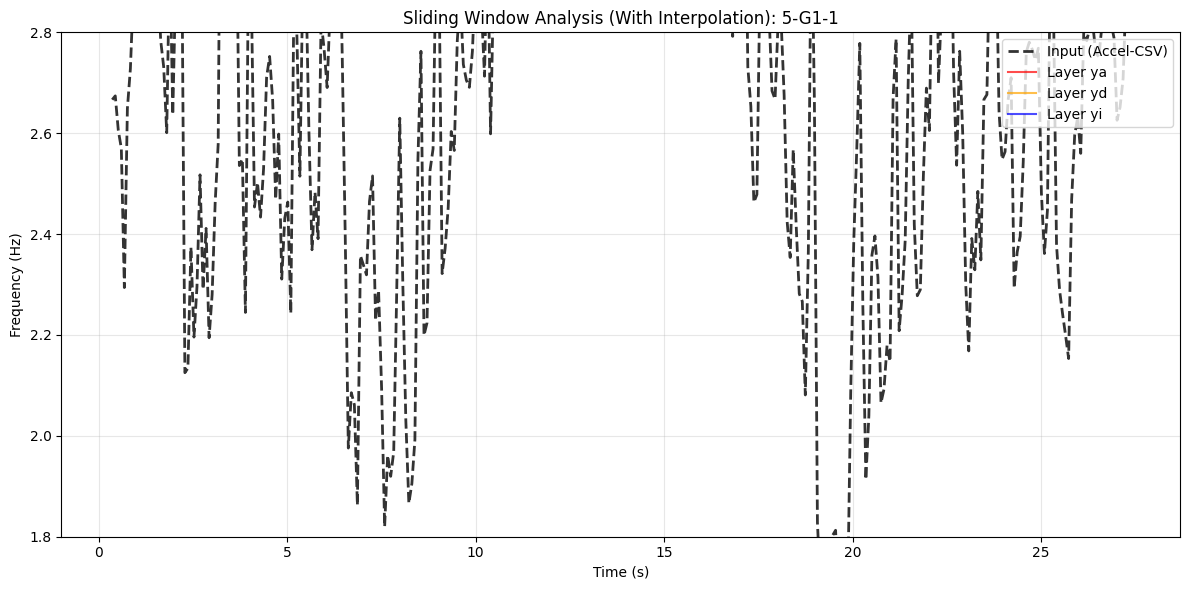

處理中: 5-G1-2


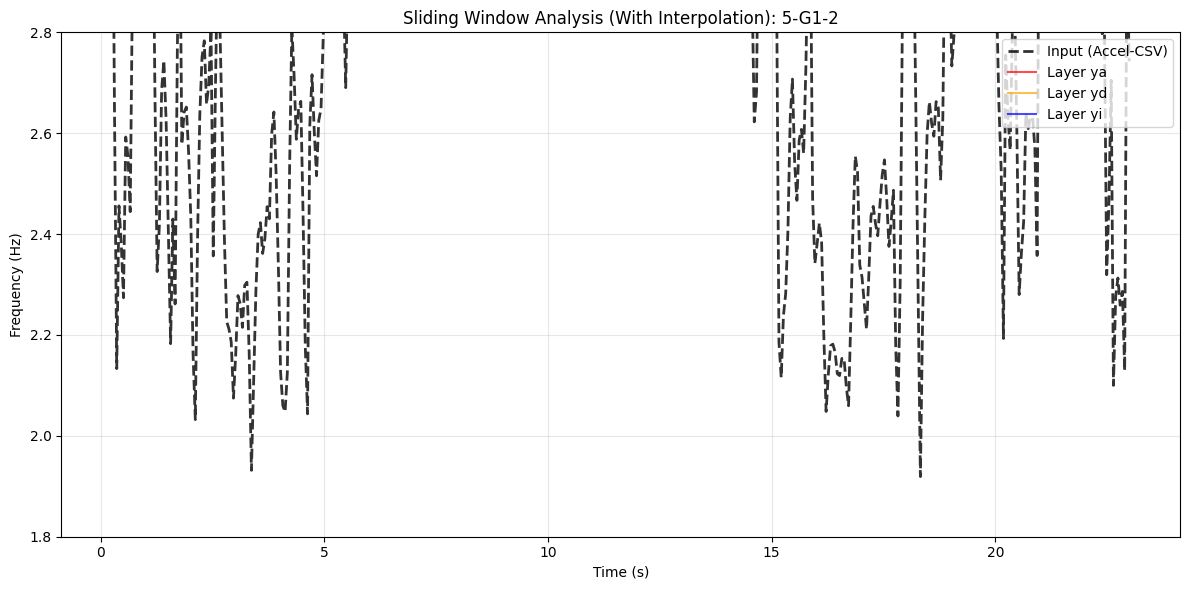

處理中: 5-G1-3


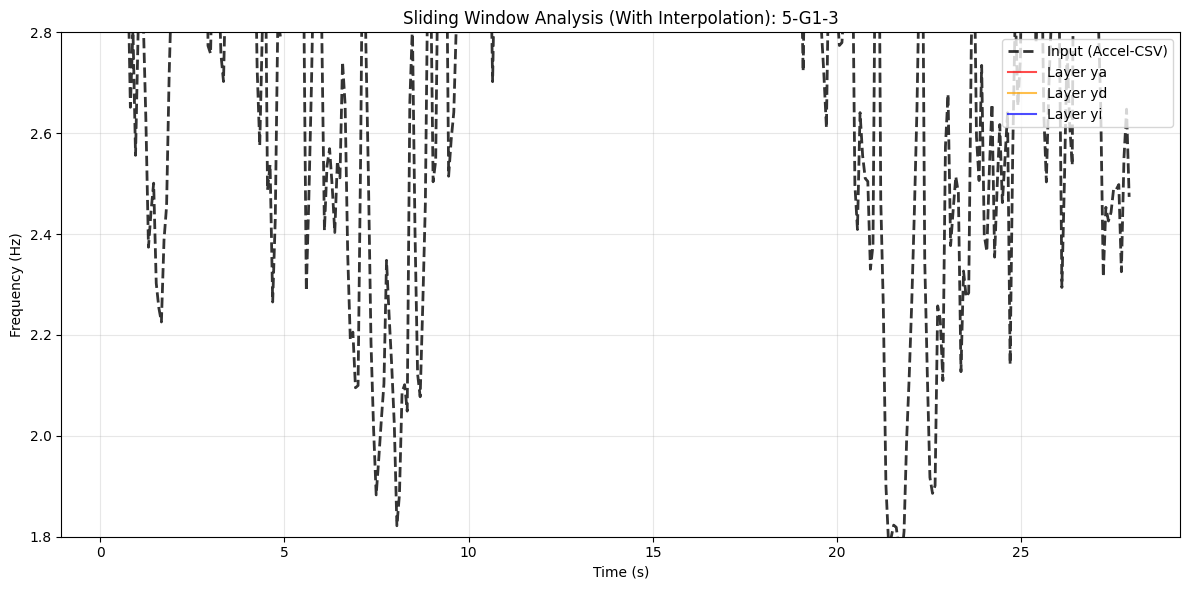

處理中: 5-G2-1


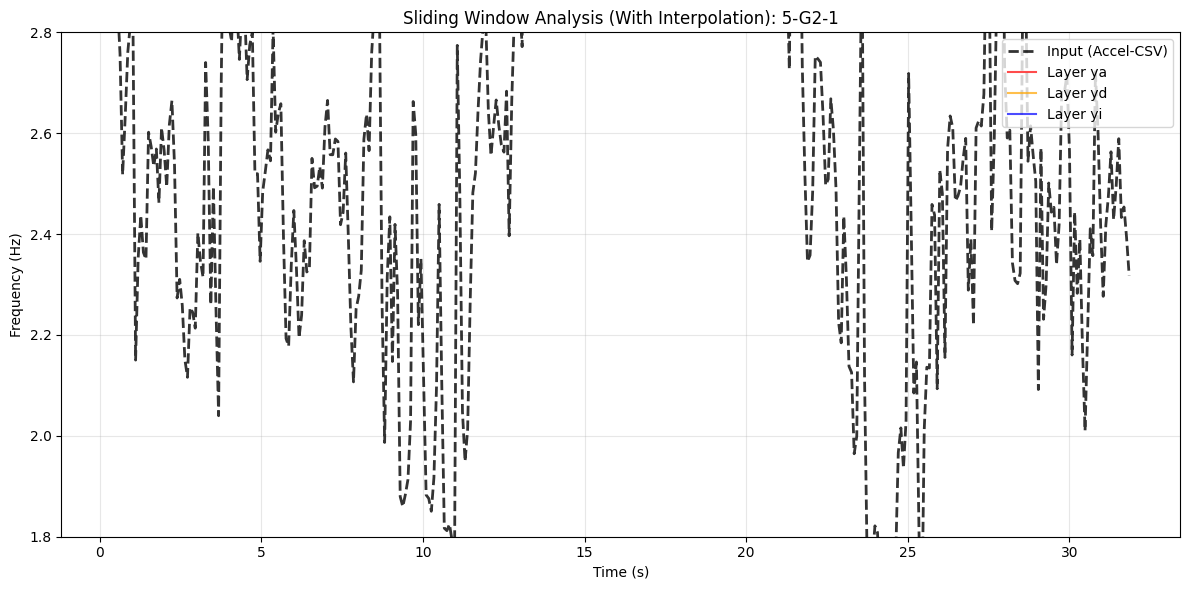

處理中: 5-G2-2


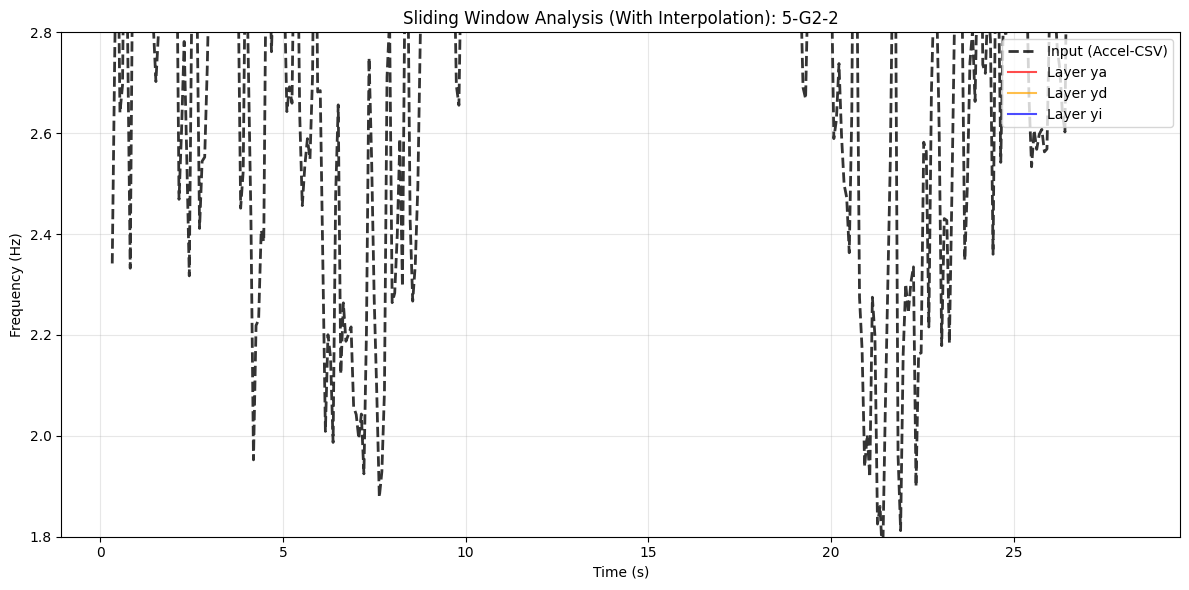

處理中: 5-G2-3


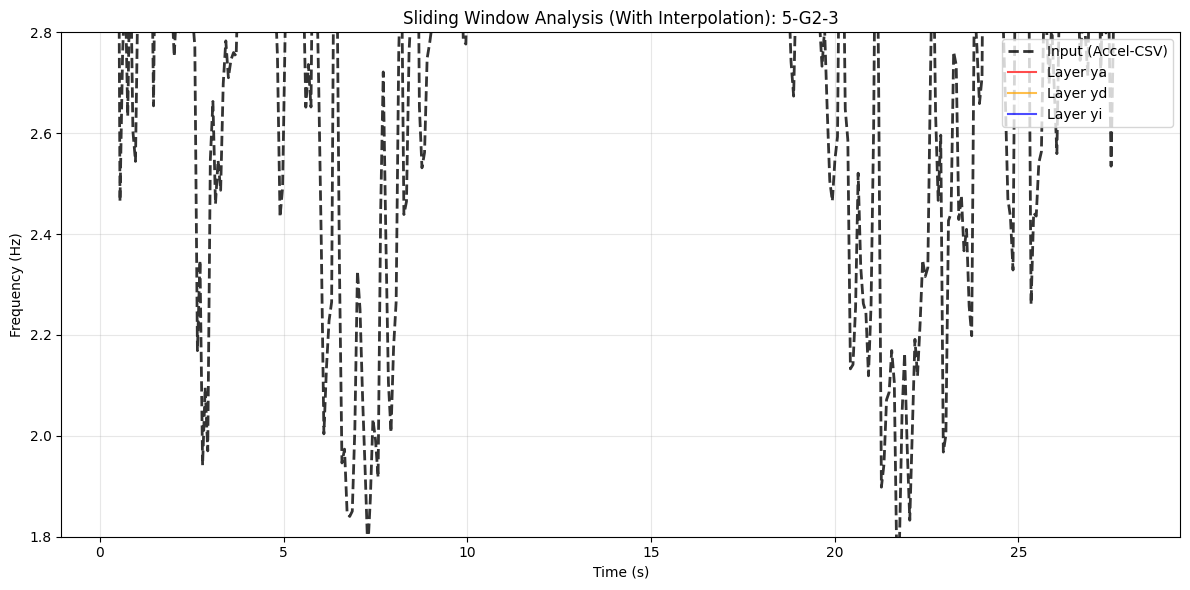

處理中: 5-G3-1


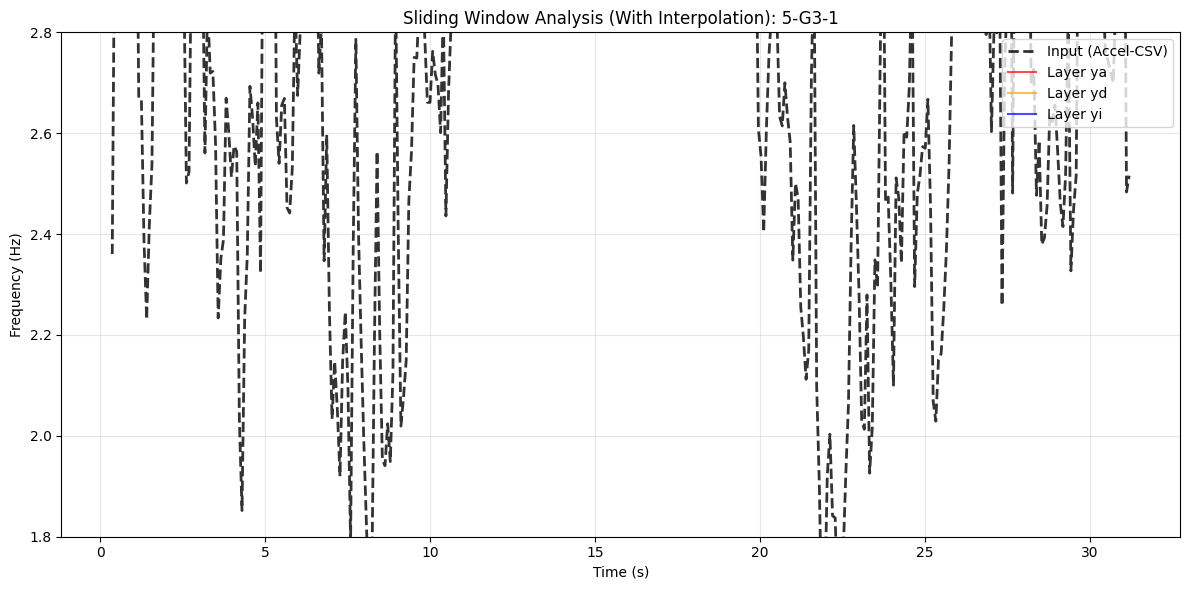

處理中: 5-G3-2


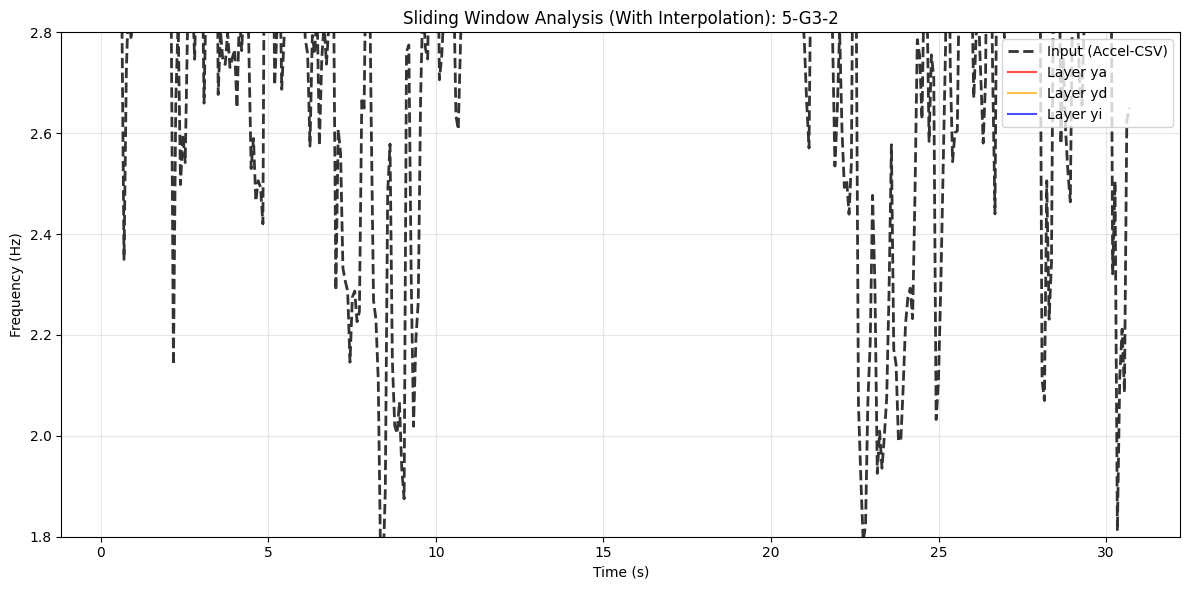

處理中: 5-G3-3


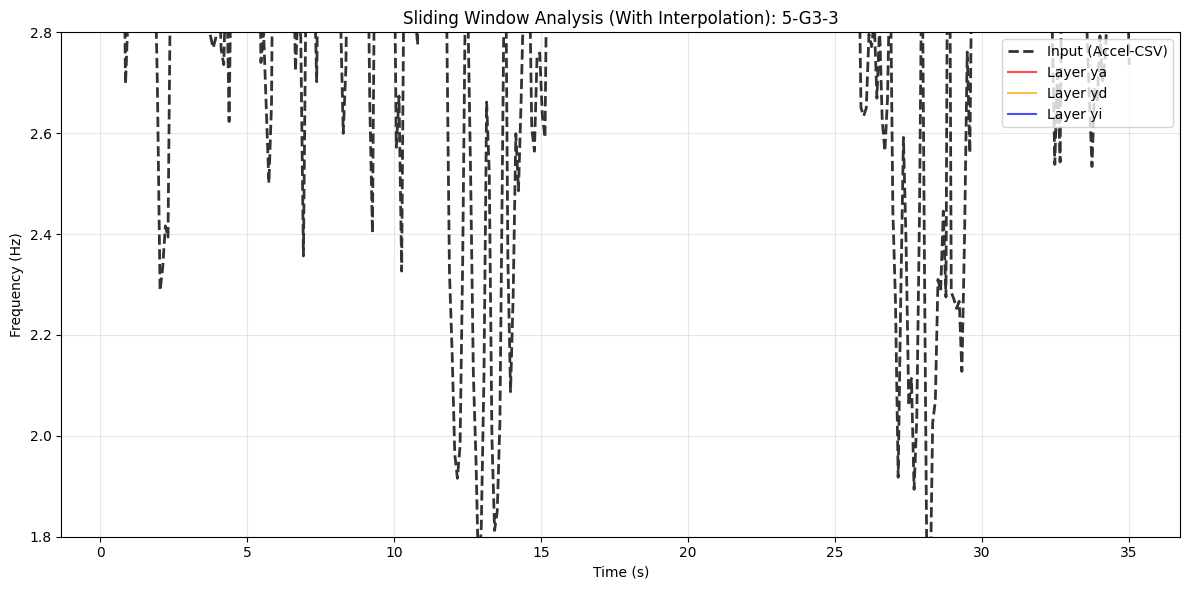

處理中: 5-G4-1


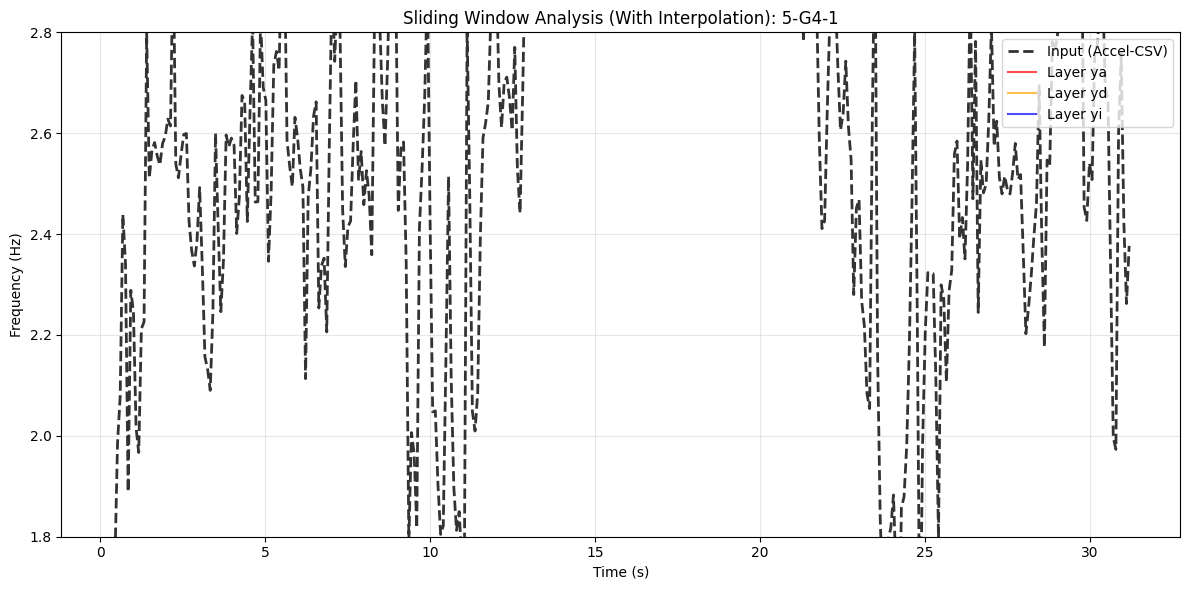

處理中: 5-G4-2


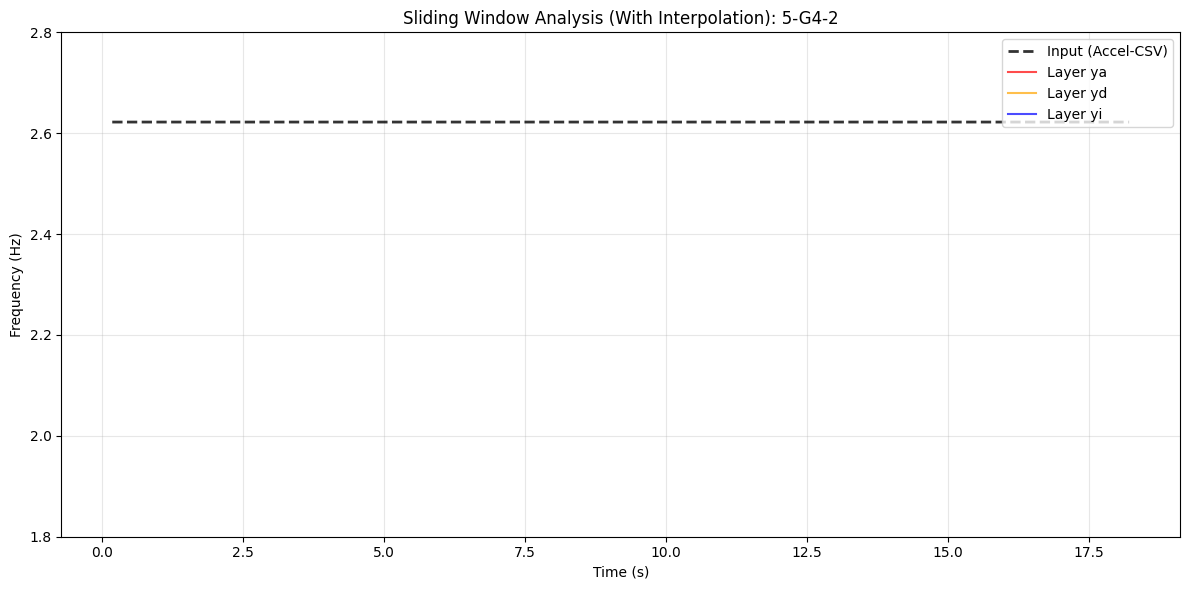

處理中: 5-G4-3


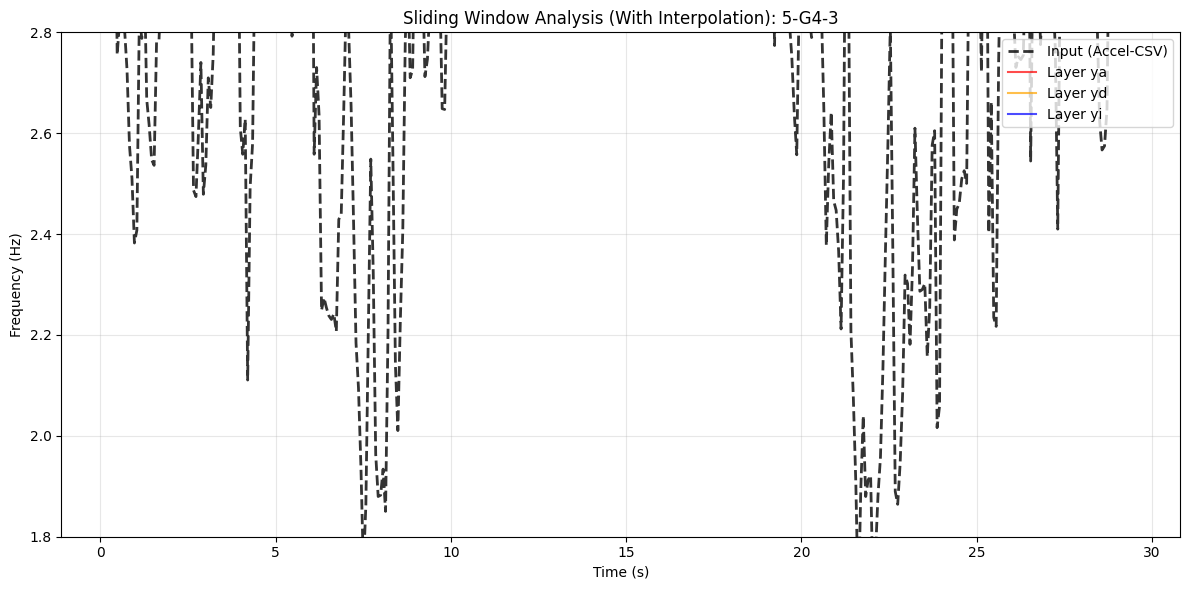

處理中: 5-G5-1


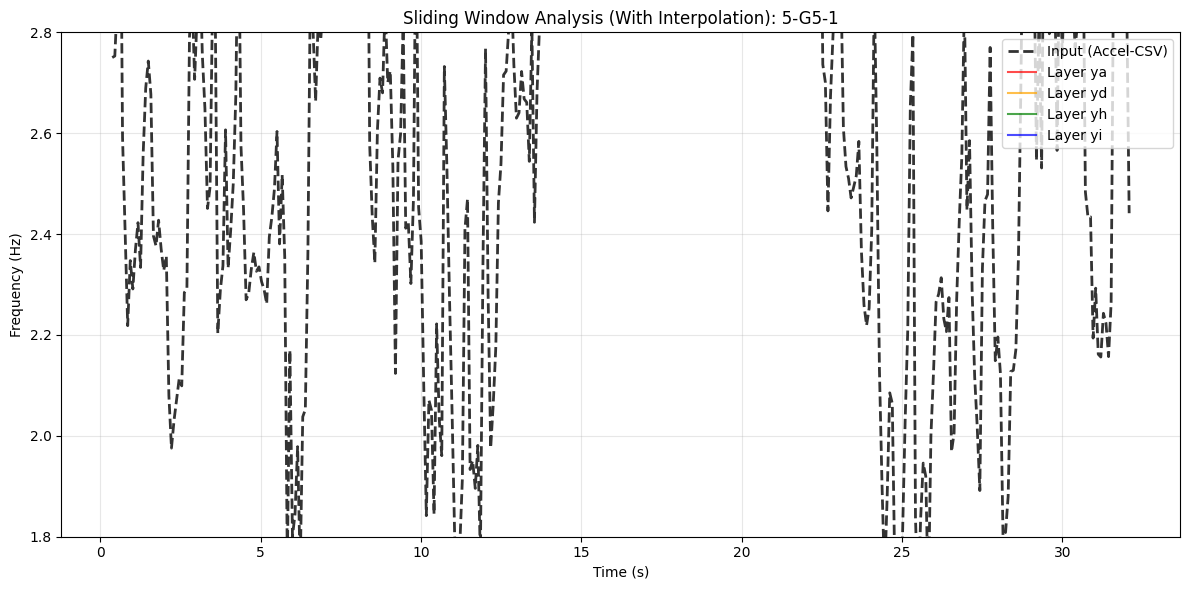

處理中: 5-G5-2


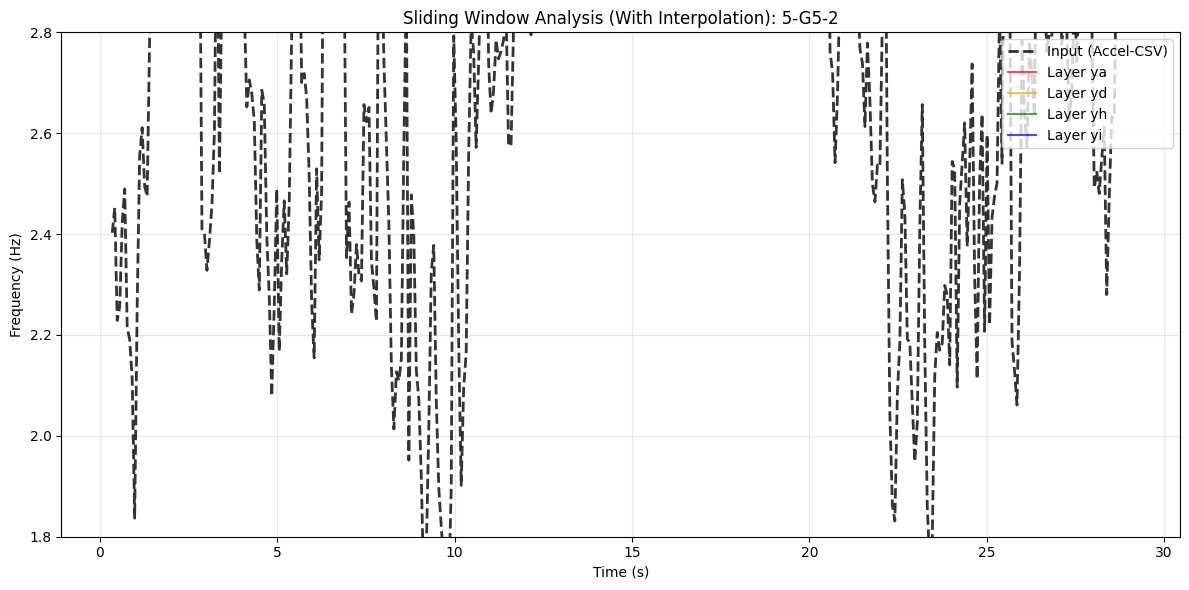

處理中: 5-G5-3


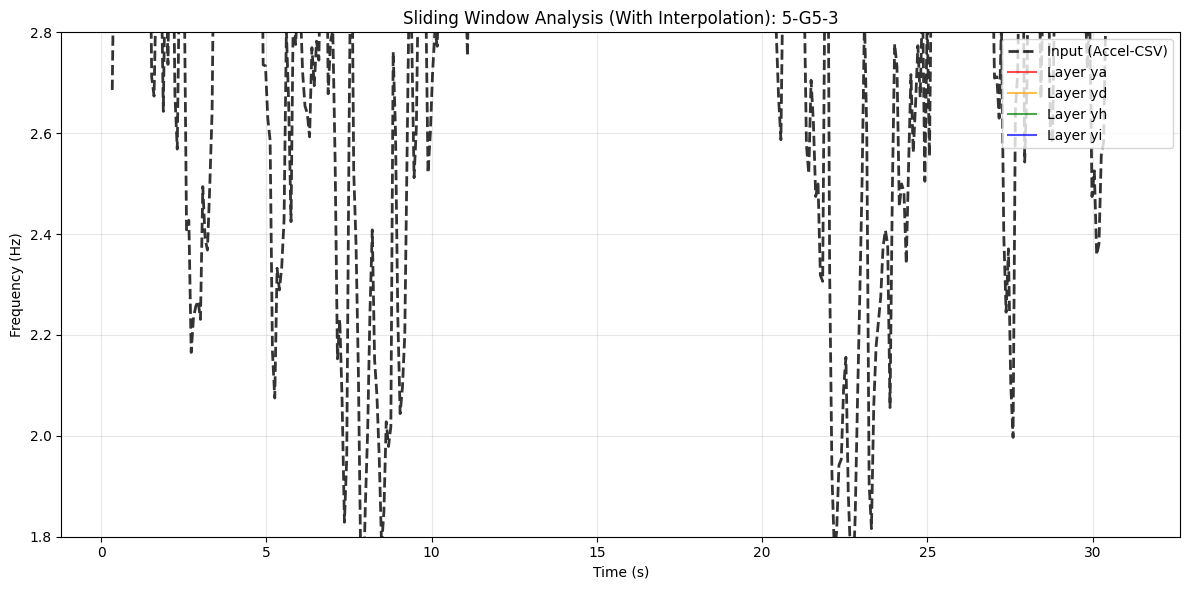

處理中: ~$5-G5-1
失敗 ~$5-G5-1: [Errno 13] Permission denied: 'E:\\EarthScienceFair_Data\\5\\G5\\~$5-G5-1.xlsx'
處理中: 5-G6-1


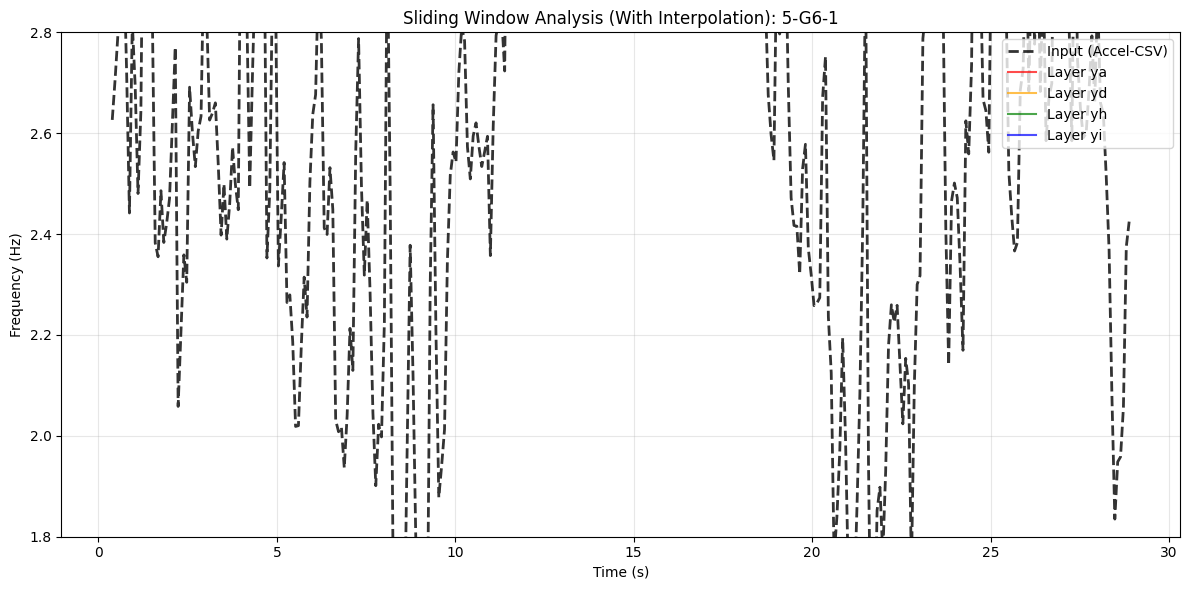

處理中: 5-G6-2


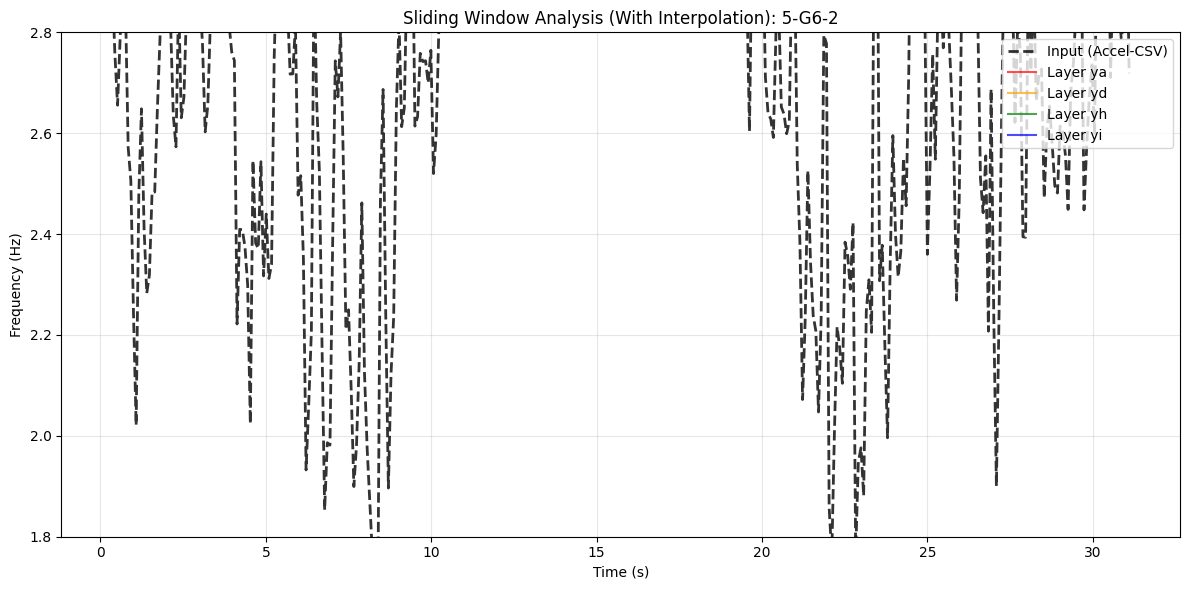

處理中: 5-G6-3


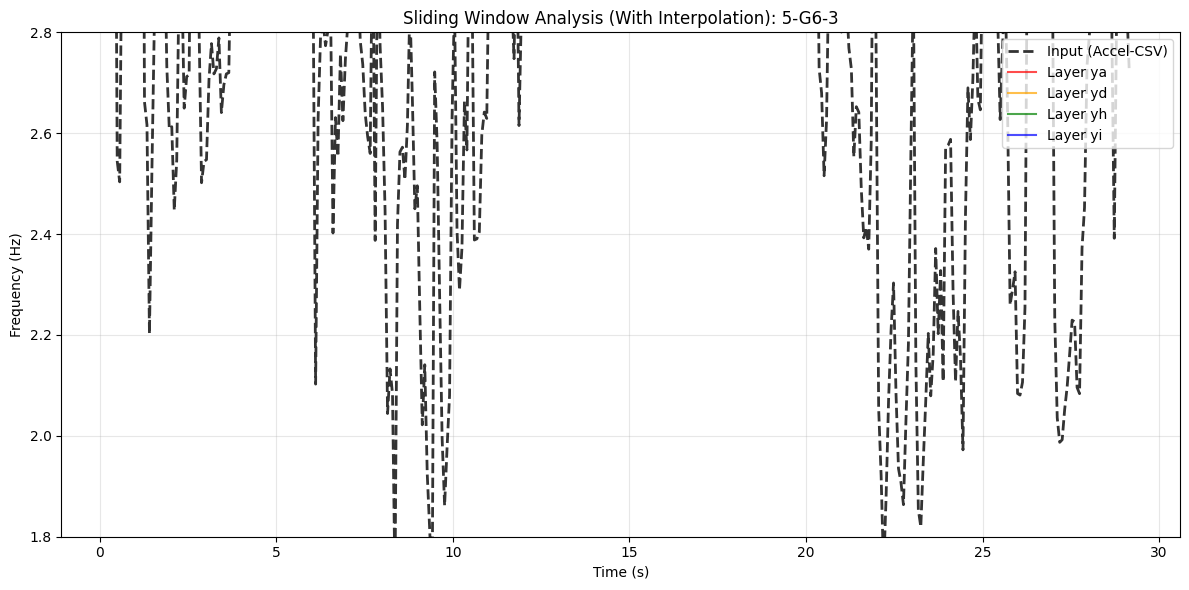

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import zipfile
from scipy.fft import fft, fftfreq
from scipy.signal import medfilt
import matplotlib.pyplot as plt

# ============================================================
# 設定與路徑
# ============================================================
base_path = r"E:\EarthScienceFair_Data"
target_folders = ["5"]
WINDOW_SIZE = 45  
STRIDE = 5       
FREQ_RANGE = (1.2, 5.0)

# ============================================================
# 工具函式 (沿用並簡化你的清理邏輯)
# ============================================================

def clean_for_window(raw_data):
    """將原始欄位轉數值、插值補坑、去中心化"""
    s = pd.to_numeric(pd.Series(raw_data), errors='coerce')
    if s.isna().all(): return np.array([])
    # 插值補齊所有 NaN，確保 FFT 時間軸連續
    s = s.interpolate(method='linear', limit_direction='both').ffill().bfill()
    val = s.values
    return val - np.mean(val) if len(val) > 0 else np.array([])

def get_sliding_freq(time, signal, win_size, stride):
    t_res, f_res = [], []
    for start in range(0, len(signal) - win_size, stride):
        end = start + win_size
        seg_t = time[start:end]
        seg_s = signal[start:end]
        
        # FFT 計算
        N = len(seg_s)
        dt = np.mean(np.diff(seg_t))
        if dt <= 0: continue
        
        yf = fft(seg_s)
        xf = fftfreq(N, dt)[:N//2]
        amp = 2.0/N * np.abs(yf[:N//2])
        
        mask = (xf >= FREQ_RANGE[0]) & (xf <= FREQ_RANGE[1])
        if np.any(mask):
            # 加權頻率
            f_main = np.sum(xf[mask] * amp[mask]) / np.sum(amp[mask])
            t_res.append(np.mean(seg_t))
            f_res.append(f_main)
    return np.array(t_res), np.array(f_res)

# ============================================================
# 主流程
# ============================================================
xlsx_files = []
for folder in target_folders:
    fp = os.path.join(base_path, folder)
    if os.path.exists(fp):
        xlsx_files.extend(glob.glob(os.path.join(fp, "**", "*.xlsx"), recursive=True))

for tracker_file in xlsx_files:
    file_id = os.path.splitext(os.path.basename(tracker_file))[0]
    print(f"處理中: {file_id}")
    
    try:
        df = pd.read_excel(tracker_file)
        
        # 1. 讀取時間軸 (強制歸零)
        t_s_raw = pd.to_numeric(df.iloc[:, 0], errors='coerce').interpolate().values
        t_s = t_s_raw - t_s_raw[0]
        
        # 2. 根據你的 iloc 定義讀取目標層位
        target_layers = {
            "ya": df.iloc[:, 1].values,
            "yd": df.iloc[:, 4].values,
            "yh": df.iloc[:, 8].values if df.shape[1] > 8 else None,
            "yi": df.iloc[:, -9].values
        }

        plt.figure(figsize=(12, 6))

        # 3. 處理手機加速度 (黑虛線)
        zip_path = os.path.join(os.path.dirname(tracker_file), f"{file_id}.zip")
        if os.path.exists(zip_path):
            with zipfile.ZipFile(zip_path, 'r') as z:
                csv_files = [f for f in z.namelist() if f.endswith('.csv')]
                if csv_files:
                    with z.open(csv_files[0]) as f:
                        acc_df = pd.read_csv(f)
                        t_acc = pd.to_numeric(acc_df.iloc[:, 0], errors='coerce').values
                        t_acc = t_acc - t_acc[0]
                        v_acc = clean_for_window(acc_df.iloc[:, -1])
                        
                        # 同步手機採樣率的視窗大小
                        ratio = len(t_acc) / len(t_s)
                        t_p, f_p = get_sliding_freq(t_acc, v_acc, int(WINDOW_SIZE*ratio), int(STRIDE*ratio))
                        plt.plot(t_p, f_p, 'k--', label="Input (Accel-CSV)", alpha=0.8, linewidth=2)

        # 4. 處理 Tracker 每一層
        colors = {"ya":"red", "yd":"orange", "yh":"green", "yi":"blue"}
        for name, raw_val in target_layers.items():
            if raw_val is None: continue
            
            clean_sig = clean_for_window(raw_val)
            if len(clean_sig) > WINDOW_SIZE:
                # 先中位數濾波去噪，再做滑動 FFT
                sig_med = medfilt(clean_sig, kernel_size=5)
                tp, fp = get_sliding_freq(t_s, sig_med, WINDOW_SIZE, STRIDE)
                plt.plot(tp, fp, color=colors[name], label=f"Layer {name}", alpha=0.7)

        # 5. 繪圖細節
        plt.ylim(1.8, 2.8)
        plt.title(f"Sliding Window Analysis (With Interpolation): {file_id}")
        plt.xlabel("Time (s)")
        plt.ylabel("Frequency (Hz)")
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.savefig(f"Sliding_{file_id}.png")
        plt.show()

    except Exception as e:
        print(f"失敗 {file_id}: {e}")